<a href="https://colab.research.google.com/github/abiduldul/Numerical-Method/blob/main/Materi%203/polynomial_regression_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  BAGIAN 3: POLYNOMIAL REGRESSION (Orde 2)

  Tabel perhitungan:
  xi     yi       xi^2     xi^3     xi^4     xi*yi      xi^2*yi   
  --------------------------------------------------------------------
  0      2.1      0        0        0        0.0        0.0       
  1      7.7      1        1        1        7.7        7.7       
  2      13.6     4        8        16       27.2       54.4      
  3      27.2     9        27       81       81.6       244.8     
  4      40.9     16       64       256      163.6      654.4     
  5      61.1     25       125      625      305.5      1527.5    
  --------------------------------------------------------------------
  Sum    152.6    55       225      979      585.6      2488.8    

  Normal Equations:
    6a + 15b + 55c = 152.6
    15a + 55b + 225c = 585.6
    55a + 225b + 979c = 2488.8

  Solusi:
    a = 2.4786
    b = 2.3593
    c = 1.8607

  Fungsi hasil: f(x) = 2.4786 + 2.3593x + 1.8607x²

  Phi (sum of squared errors) = 3.74657

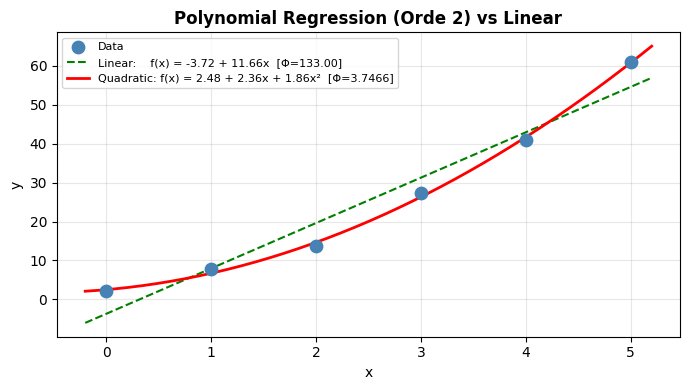

In [ ]:
# ============================================================
#  BAGIAN 3: POLYNOMIAL REGRESSION
#  Contoh dari Slide (Example 3)
#  Data: x = [0..5], y = [2.1, 7.7, 13.6, 27.2, 40.9, 61.1]
#  Model: f(x) = a + b*x + c*x²
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

print("\n" + "=" * 60)
print("  BAGIAN 3: POLYNOMIAL REGRESSION (Orde 2)")
print("=" * 60)

# --- Data ---
x3 = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y3 = np.array([2.1, 7.7, 13.6, 27.2, 40.9, 61.1], dtype=float)
n3 = len(x3)

# --- Tabel suku-suku ---
print("\n  Tabel perhitungan:")
header3 = f"  {'xi':<6} {'yi':<8} {'xi^2':<8} {'xi^3':<8} {'xi^4':<8} {'xi*yi':<10} {'xi^2*yi':<10}"
print(header3)
print("  " + "-"*68)
for i in range(n3):
    print(f"  {x3[i]:<6.0f} {y3[i]:<8.1f} {x3[i]**2:<8.0f} {x3[i]**3:<8.0f} "
          f"{x3[i]**4:<8.0f} {x3[i]*y3[i]:<10.1f} {x3[i]**2*y3[i]:<10.1f}")
print("  " + "-"*68)
print(f"  {'Sum':<6} {np.sum(y3):<8.1f} {np.sum(x3**2):<8.0f} {np.sum(x3**3):<8.0f} "
      f"{np.sum(x3**4):<8.0f} {np.sum(x3*y3):<10.1f} {np.sum(x3**2*y3):<10.1f}")

# --- Normal Equations (3x3) ---
# n*a + Σx*b + Σx²*c = Σy
# Σx*a + Σx²*b + Σx³*c = Σxy
# Σx²*a + Σx³*b + Σx⁴*c = Σx²y

A3 = np.array([
    [n3,              np.sum(x3),    np.sum(x3**2)],
    [np.sum(x3),      np.sum(x3**2), np.sum(x3**3)],
    [np.sum(x3**2),   np.sum(x3**3), np.sum(x3**4)]
])
B3 = np.array([np.sum(y3), np.sum(x3*y3), np.sum(x3**2*y3)])

sol3 = np.linalg.solve(A3, B3)
a3, b3, c3 = sol3[0], sol3[1], sol3[2]

print(f"\n  Normal Equations:")
print(f"    {n3}a + {np.sum(x3):.0f}b + {np.sum(x3**2):.0f}c = {np.sum(y3):.1f}")
print(f"    {np.sum(x3):.0f}a + {np.sum(x3**2):.0f}b + {np.sum(x3**3):.0f}c = {np.sum(x3*y3):.1f}")
print(f"    {np.sum(x3**2):.0f}a + {np.sum(x3**3):.0f}b + {np.sum(x3**4):.0f}c = {np.sum(x3**2*y3):.1f}")

print(f"\n  Solusi:")
print(f"    a = {a3:.4f}")
print(f"    b = {b3:.4f}")
print(f"    c = {c3:.4f}")
print(f"\n  Fungsi hasil: f(x) = {a3:.4f} + {b3:.4f}x + {c3:.4f}x²")

y3_pred = a3 + b3*x3 + c3*x3**2
phi3 = np.sum((y3_pred - y3)**2)
print(f"\n  Phi (sum of squared errors) = {phi3:.6f}")

# --- Bandingkan dengan Linear juga ---
A3_lin = np.array([[n3, np.sum(x3)],
                   [np.sum(x3), np.sum(x3**2)]])
B3_lin = np.array([np.sum(y3), np.sum(x3*y3)])
sol3_lin = np.linalg.solve(A3_lin, B3_lin)
a3l, b3l = sol3_lin
y3_pred_lin = a3l + b3l*x3
phi3_lin = np.sum((y3_pred_lin - y3)**2)

print(f"\n  Perbandingan model:")
print(f"    Linear    → Phi = {phi3_lin:.4f}  (lebih besar = lebih buruk)")
print(f"    Quadratic → Phi = {phi3:.4f}  (lebih kecil = lebih baik ✓)")

# --- Plot ---
fig3, ax3 = plt.subplots(figsize=(7, 4))
x3_line = np.linspace(-0.2, 5.2, 200)
y3_lin_line  = a3l + b3l*x3_line
y3_quad_line = a3 + b3*x3_line + c3*x3_line**2
ax3.scatter(x3, y3, color='steelblue', s=80, zorder=5, label='Data')
ax3.plot(x3_line, y3_lin_line,  'g--', linewidth=1.5,
         label=f'Linear:    f(x) = {a3l:.2f} + {b3l:.2f}x  [Φ={phi3_lin:.2f}]')
ax3.plot(x3_line, y3_quad_line, 'r-',  linewidth=2,
         label=f'Quadratic: f(x) = {a3:.2f} + {b3:.2f}x + {c3:.2f}x²  [Φ={phi3:.4f}]')
for i in range(n3):
    ax3.plot([x3[i], x3[i]], [y3[i], y3_pred[i]], 'gray',
             linestyle=':', linewidth=1)
ax3.set_title('Polynomial Regression (Orde 2) vs Linear', fontsize=12, fontweight='bold')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()